In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings
import fastf1
import os
from matplotlib.collections import LineCollection

warnings.filterwarnings('ignore')

# 1. DATA EXTRACTION & SETUP
# IMPORTANT: Make sure you have a folder named 'cache' in your directory

In [21]:
path = os.getcwd()+"/cache/"
if not os.path.exists(path):
    os.mkdir(path=path)

In [5]:
fastf1.Cache.enable_cache('cache') 

print("Descargando datos del GP de Gran Bretaña 2020...")
session = fastf1.get_session(2020, 'Silverstone', 'R')
session.load()

# Seleccionamos a Lewis Hamilton (HAM)
laps_ham = session.laps.pick_driver('HAM')

core           INFO 	Loading data for British Grand Prix - Race [v3.0.2]
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...


Descargando datos del GP de Gran Bretaña 2020...


req            INFO 	Data has been written to cache!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
_api        WARNING 	Driver  4: Ignoring late data for a prev

# 2. Creating the Minority Class (Imbalance Target)
# We consider an "Anomaly/Degradation" (Class 1) to be laps 5% slower than the median

In [6]:
median_time = laps_ham['LapTime'].median()
threshold_time = median_time * 1.05 

# Labeling: 1 if anomaly, 0 if normal
laps_ham['Is_Anomaly'] = ((laps_ham['LapTime'] > threshold_time) | pd.isnull(laps_ham['LapTime'])).astype(int)

# 3. Extracting Telemetry (Time Series)

In [8]:
print("Extracting lap-by-lap telemetry...")
telemetry_data = pd.DataFrame()

for index, lap in laps_ham.iterlaps():
    try:
        telemetry = lap.get_telemetry()
        telemetry['LapNumber'] = lap['LapNumber']
        telemetry['Is_Anomaly'] = lap['Is_Anomaly']
        telemetry_data = pd.concat([telemetry_data, telemetry], ignore_index=True)
    except:
        continue

# Filter the core features for our multivariate dataset
features = ['Speed', 'RPM', 'nGear', 'Throttle', 'Brake']
telemetry_data = telemetry_data.dropna(subset=features)

Extracting lap-by-lap telemetry...


# 4. EXPLORATORY DATA ANALYSIS (EDA) PLOTS

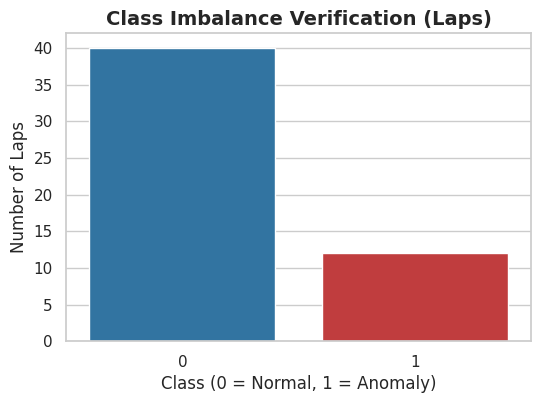

In [9]:
sns.set_theme(style="whitegrid")

# Plot 1: Class Imbalance Verification
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=laps_ham, x='Is_Anomaly', palette=['#1f77b4', '#d62728'])
plt.title('Class Imbalance Verification (Laps)', fontsize=14, fontweight='bold')
plt.xlabel('Class (0 = Normal, 1 = Anomaly)')
plt.ylabel('Number of Laps')
plt.show()

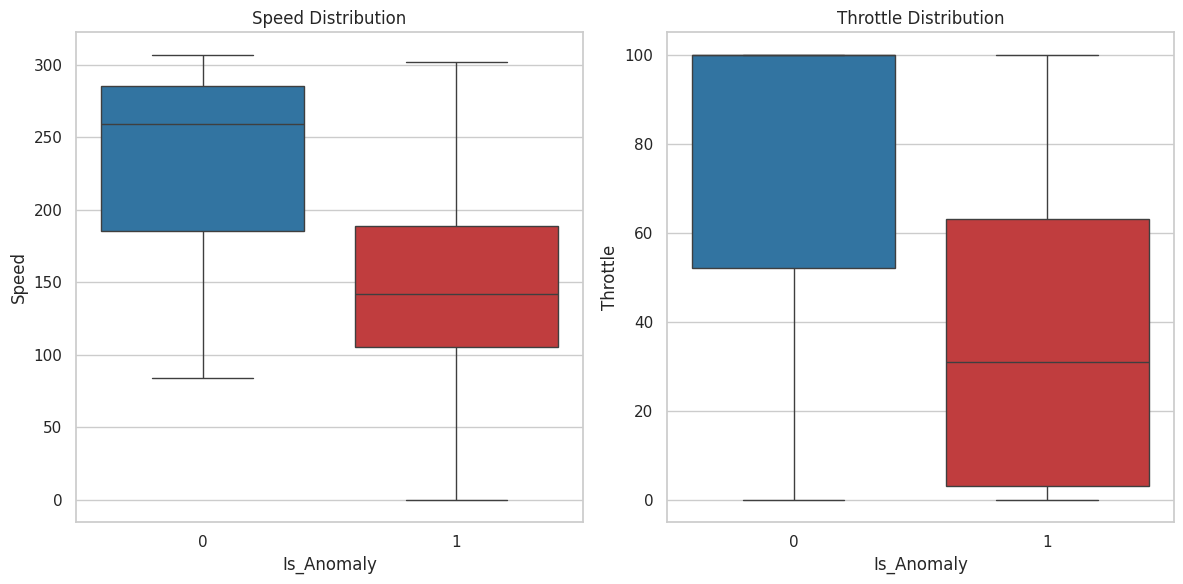

In [11]:
# Plot 2: Feature Distribution (Boxplots)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=telemetry_data, x='Is_Anomaly', y='Speed', palette=['#1f77b4', '#d62728'])
plt.title('Speed Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=telemetry_data, x='Is_Anomaly', y='Throttle', palette=['#1f77b4', '#d62728'])
plt.title('Throttle Distribution')
plt.tight_layout()
plt.show()

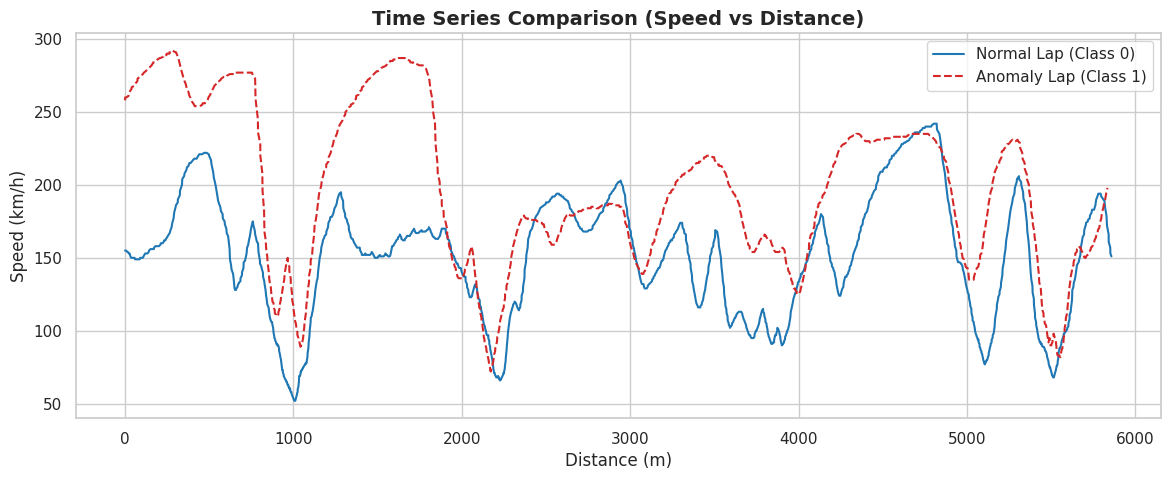

In [12]:
# Plot 3: Time Series Visualization (Comparing Laps)
normal_lap = telemetry_data[telemetry_data['LapNumber'] == 15] # Standard race pace lap
anomaly_lap = telemetry_data[telemetry_data['LapNumber'] == 52] # Final lap (puncture)

plt.figure(figsize=(14, 5))
plt.plot(normal_lap['Distance'], normal_lap['Speed'], label='Normal Lap (Class 0)', color='#1f77b4')
if not anomaly_lap.empty:
    plt.plot(anomaly_lap['Distance'], anomaly_lap['Speed'], label='Anomaly Lap (Class 1)', color='#d62728', linestyle='--')
plt.title('Time Series Comparison (Speed vs Distance)', fontsize=14, fontweight='bold')
plt.xlabel('Distance (m)')
plt.ylabel('Speed (km/h)')
plt.legend()
plt.show()

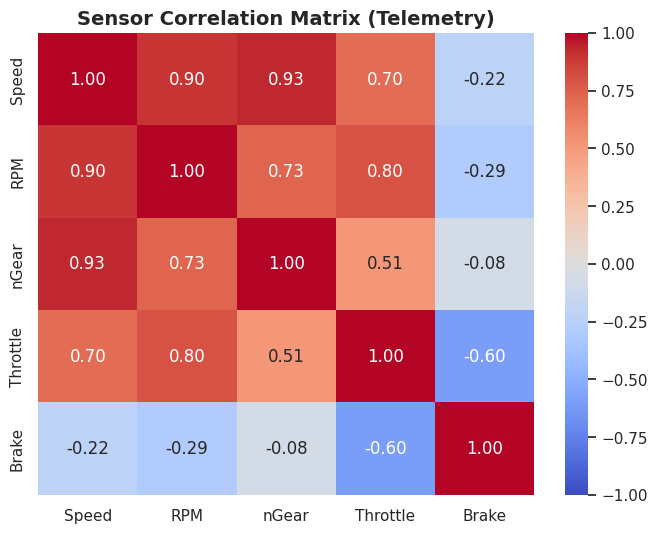

In [13]:
# Plot 4: Correlation Analysis
plt.figure(figsize=(8, 6))
corr_matrix = telemetry_data[features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Sensor Correlation Matrix (Telemetry)', fontsize=14, fontweight='bold')
plt.show()

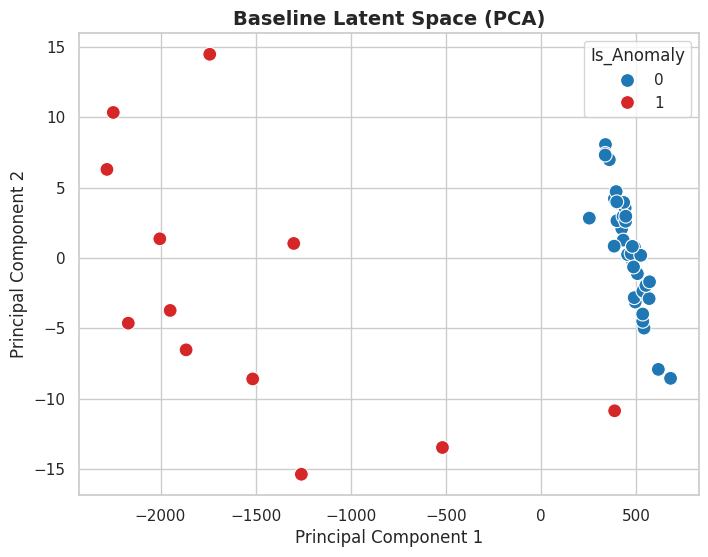

In [15]:
# Plot 5: PCA / Baseline Latent Space
lap_summary = telemetry_data.groupby('LapNumber')[features].mean().reset_index()
lap_labels = laps_ham[['LapNumber', 'Is_Anomaly']].drop_duplicates()
pca_data = pd.merge(lap_summary, lap_labels, on='LapNumber')

pca = PCA(n_components=2)
components = pca.fit_transform(pca_data[features])

plt.figure(figsize=(8, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=pca_data['Is_Anomaly'], palette=['#1f77b4', '#d62728'], s=100)
plt.title('Baseline Latent Space (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# 5. PREPARING THE 3D TENSOR FOR DEEP LEARNING

In [18]:
print("\nPreparing data for Deep Learning...")

# Scale the data (CRITICAL for the VAE to converge properly)
scaler = StandardScaler()
telemetry_data[features] = scaler.fit_transform(telemetry_data[features])

# Define a fixed sequence length (Truncating/Padding)
TIME_STEPS = 600 

X_list = []
y_list = []

for lap_num, group in telemetry_data.groupby('LapNumber'):
    lap_array = group[features].values
    
    # Truncate if too long
    if len(lap_array) > TIME_STEPS:
        lap_array = lap_array[:TIME_STEPS, :]
    # Pad with zeros if too short
    elif len(lap_array) < TIME_STEPS:
        padding = np.zeros((TIME_STEPS - len(lap_array), len(features)))
        lap_array = np.vstack((lap_array, padding))
        
    X_list.append(lap_array)
    y_list.append(group['Is_Anomaly'].iloc[0])

# Convert to 3D NumPy Arrays
X = np.array(X_list)
y = np.array(y_list)

print(f"Shape of Tensor X (Data): {X.shape} -> (samples, time_steps, features)")
print(f"Shape of Tensor y (Labels): {y.shape}")
print(f"Normal Laps (Class 0): {np.sum(y == 0)}")
print(f"Anomaly Laps (Class 1): {np.sum(y == 1)}")


Preparing data for Deep Learning...
Shape of Tensor X (Data): (52, 600, 5) -> (samples, time_steps, features)
Shape of Tensor y (Labels): (52,)
Normal Laps (Class 0): 40
Anomaly Laps (Class 1): 12


# Given a driver and a track, all of the data that is available

In [22]:
# Get Hamilton's laps and his absolute fastest lap
laps_ham = session.laps.pick_driver('HAM')
fastest_lap = laps_ham.pick_fastest()
telemetry = fastest_lap.get_telemetry()

# CATEGORY 1: COMPLETE CAR TELEMETRY
# This shows exactly what the driver is doing with the pedals, steering, and engine.

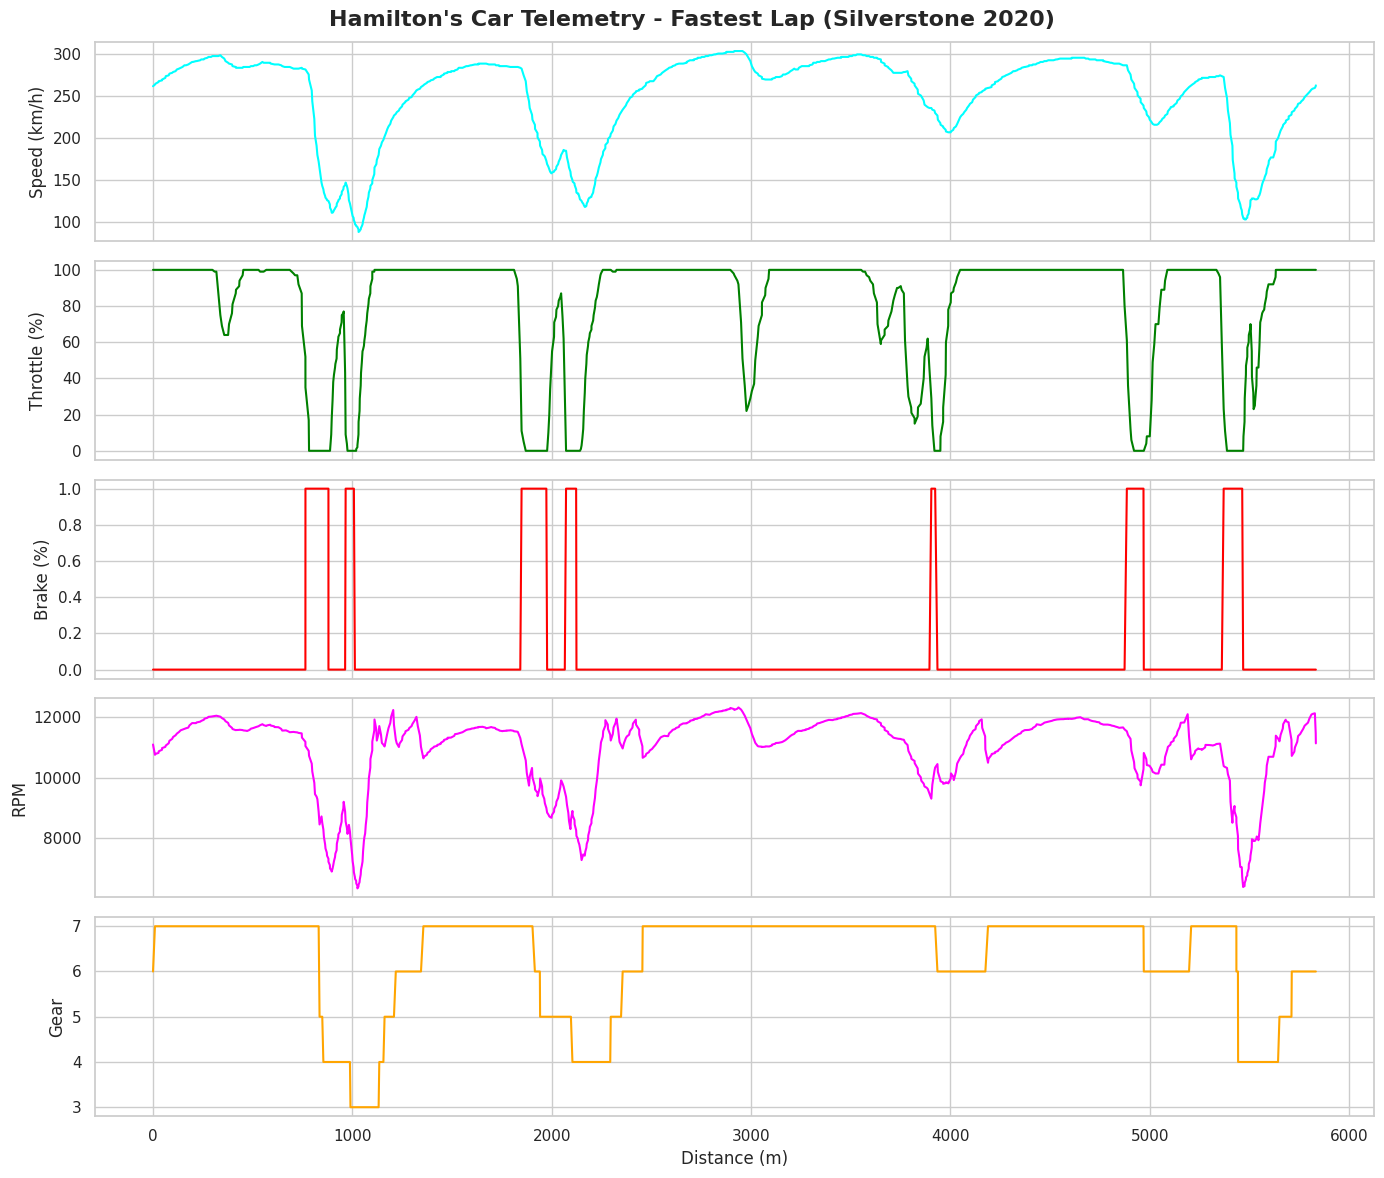

In [23]:
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)
fig.suptitle("Hamilton's Car Telemetry - Fastest Lap (Silverstone 2020)", fontsize=16, fontweight='bold')

# Speed
axes[0].plot(telemetry['Distance'], telemetry['Speed'], color='cyan')
axes[0].set_ylabel('Speed (km/h)')
# Throttle
axes[1].plot(telemetry['Distance'], telemetry['Throttle'], color='green')
axes[1].set_ylabel('Throttle (%)')
# Brake
axes[2].plot(telemetry['Distance'], telemetry['Brake'], color='red')
axes[2].set_ylabel('Brake (%)')
# RPM
axes[3].plot(telemetry['Distance'], telemetry['RPM'], color='magenta')
axes[3].set_ylabel('RPM')
# Gear
axes[4].plot(telemetry['Distance'], telemetry['nGear'], color='orange')
axes[4].set_ylabel('Gear')
axes[4].set_xlabel('Distance (m)')

plt.tight_layout()
plt.show()

# CATEGORY 2: TRACK DATA & POSITIONING (GRAPH)
# The telemetry includes X, Y, and Z coordinates.
# We will draw the track and color it by Speed to see where he brakes and accelerates.

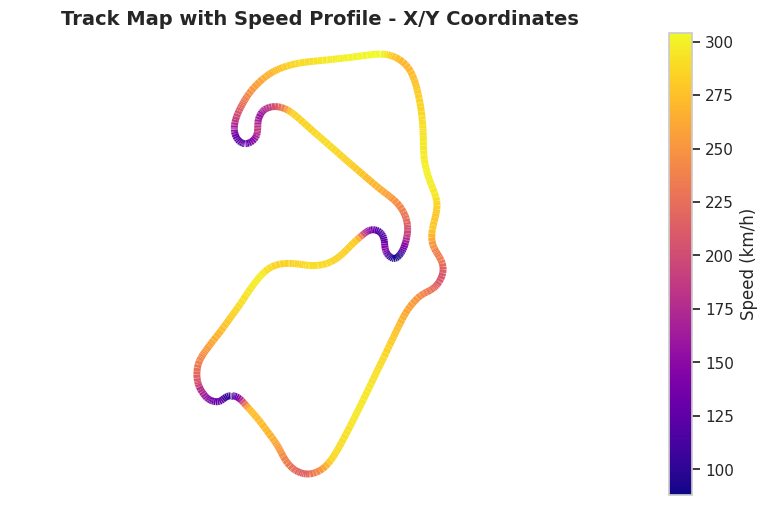

In [26]:
x = telemetry['X']
y = telemetry['Y']
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
# Create a continuous norm to map from data points to colors
norm = plt.Normalize(telemetry['Speed'].min(), telemetry['Speed'].max())
lc = LineCollection(segments, cmap='plasma', norm=norm, linewidth=5)
lc.set_array(telemetry['Speed'])
line = ax.add_collection(lc)

fig.colorbar(line, ax=ax, label='Speed (km/h)')
ax.set_title("Track Map with Speed Profile - X/Y Coordinates", fontsize=14, fontweight='bold')
ax.axis('equal') # Keep the track proportions accurate
plt.axis('off')  # Hide grid lines for a clean look
plt.show()

# CATEGORY 3: LAP, TIRE & SECTOR DATA (TABLE)
# This is lower-frequency data (recorded once per lap).
# We select the most important columns and show the first 5 laps.

In [27]:
lap_features = ['LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time', 
                'Compound', 'TyreLife', 'FreshTyre', 'TrackStatus']

# Convert timedelta to seconds for better readability in the table
laps_display = laps_ham[lap_features].copy()
laps_display['LapTime'] = laps_display['LapTime'].dt.total_seconds()
laps_display['Sector1Time'] = laps_display['Sector1Time'].dt.total_seconds()
laps_display['Sector2Time'] = laps_display['Sector2Time'].dt.total_seconds()

print("\n--- LAP & TIRE DATA (FIRST 5 LAPS) ---")
display(laps_display.head()) 


--- LAP & TIRE DATA (FIRST 5 LAPS) ---


,LapNumber,LapTime,Sector1Time,Sector2Time,Compound,TyreLife,FreshTyre,TrackStatus
430,1.0,NaN,NaN,37.157,MEDIUM,4.0,False,1
431,2.0,126.445,34.863,54.807,MEDIUM,5.0,False,24
432,3.0,NaN,50.254,59.842,MEDIUM,6.0,False,4
433,4.0,NaN,46.827,64.918,MEDIUM,7.0,False,4
434,5.0,138.933,43.592,59.048,MEDIUM,8.0,False,4


# CATEGORY 4: WEATHER & ENVIRONMENT (GRAPH)
# Weather impacts tire degradation heavily, which is crucial for your anomaly detection.

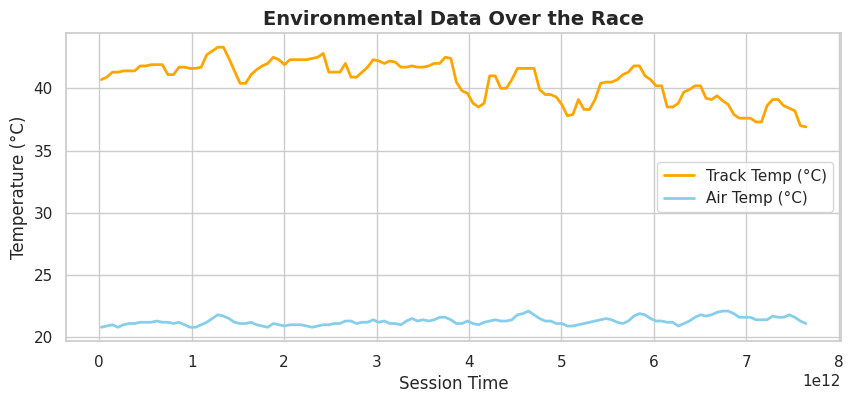

In [28]:
weather_data = session.weather_data

plt.figure(figsize=(10, 4))
plt.plot(weather_data['Time'], weather_data['TrackTemp'], label='Track Temp (°C)', color='orange', linewidth=2)
plt.plot(weather_data['Time'], weather_data['AirTemp'], label='Air Temp (°C)', color='skyblue', linewidth=2)
plt.title("Environmental Data Over the Race", fontsize=14, fontweight='bold')
plt.xlabel("Session Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [29]:
weather_data = session.weather_data.copy()

weather_data['Time'] = weather_data['Time'].dt.total_seconds()

print("\n--- COMPLETE WEATHER DATA (FIRST 5 SAMPLES) ---")

display(weather_data.head())


--- COMPLETE WEATHER DATA (FIRST 5 SAMPLES) ---


,Time,AirTemp,Humidity,Pressure,Rainfall,TrackTemp,WindDirection,WindSpeed
0,23.418,20.8,44.6,998.6,False,40.7,209,3.2
1,83.420,20.9,44.7,998.7,False,40.9,200,3.8
2,143.421,21.0,43.8,998.6,False,41.3,217,4.2
3,203.422,20.8,44.7,998.6,False,41.3,232,3.2
4,263.425,21.0,44.8,998.6,False,41.4,209,3.5
